In [92]:
from src.base import BaseImage
from src.tissue import process_image, scale_image
from dataclasses import dataclass, field
from src.constant import ProcessingParams
import cv2
import json
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
import os
from pathlib import Path
import numpy as np


In [93]:
@dataclass
class Params:
    img_path: str = "data/test.bmp"
    bin_threshold: int = 0
    rotate: int = 0
    debug: bool = False
    rectangle_model: str = "bin"
    scale_factor: float = 0.7
    grid_size: tuple[int, int] = (1426, 1656)
    gap_ratio: float = 1.0
    activation_threshold: float = 0.08
    block_threshold: int = 150
    dbscan_min_samples: int = 7
    threshold_mode: str = "gray-max"
    threshold: dict = field(
        default_factory=lambda: {"saturation": None, "hue": None, "value": 175}
    )
    type: str = "s3000"  # 'square' | 'dy' | 's3000'


### Load Image

In [94]:
img_path = "data/260311/260311-SPA-816.bmp"

In [95]:
params = Params(
    img_path=img_path,
    debug=True,
    bin_threshold=0,
    rotate=0,
    scale_factor=1,
    grid_size=(66, 77),
    type="dy",
    activation_threshold=0.10,
    block_threshold=0,
    threshold_mode="gray-max",
    threshold={"saturation": None, "hue": None, "value": 130},
)

side_x_ratio = 1.0


### Get Cropped Image

In [96]:
img = BaseImage(
    params.img_path,
    threshold=params.bin_threshold,
    rotate=params.rotate,
    debug=params.debug,
    scale=1.0,
)
hull = img.find_largest_rectangle(params.rectangle_model)
cropped_img = img.crop_image(hull)

### Get image hist

In [97]:
# hists = get_image_hist(cropped_img)
# hist = plot_hist(hists)
# hist.show()

In [98]:
# plt.imshow(cropped_img[:, :, ::-1])

### Generate data

In [108]:
params.threshold_mode = "raw"
params.threshold = {"saturation": 15, "hue": None, "value": None}


In [109]:
process_params = ProcessingParams(
    scale_factor=params.scale_factor,
    grid_size=params.grid_size,
    activation_threshold=params.activation_threshold,
    dbscan_min_samples=params.dbscan_min_samples,
    block_threshold=params.block_threshold,
    type=params.type,
)

thresholded_img, matrix, res, rect_hull = process_image(
    img.img_raw,
    hull,
    params.threshold_mode,
    params=process_params,
    thresholds=params.threshold,
    side_x_ratio=side_x_ratio,
)

process_params


side_x 6593.0 6593.0 1.000455235204856
gap_size and r: (np.float64(100.04552352048559), np.float64(85.03869499241276)) 20.00910470409712


ProcessingParams(scale_factor=1, grid_size=(66, 77), gap_ratio=1.0, dbscan_eps=2, dbscan_min_samples=7, activation_threshold=0.1, block_threshold=0, type='dy')

In [110]:
fig = plt.figure(tight_layout=True, figsize=(16, 5))

grid_size = res.get("grid_size", process_params.grid_size)
block_size = res.get("block_size") if params.type == "square" else None
spot_radius = res.get("r") if params.type in ("dy", "s3000") else None

tissue_img = img.get_cropped_tissue(
    rect_hull,
    matrix,
    process_params.scale_factor,
    grid_size,
    res["gap_size"],
    block_size,
    spot_radius,
    params.type,
)
cv2.imwrite("test.png", tissue_img)

20
(np.float64(100.04552352048559), np.float64(85.03869499241276)) 20.00910470409712


True

<Figure size 1600x500 with 0 Axes>

20
(np.float64(100.04552352048559), np.float64(85.03869499241276)) 20.00910470409712


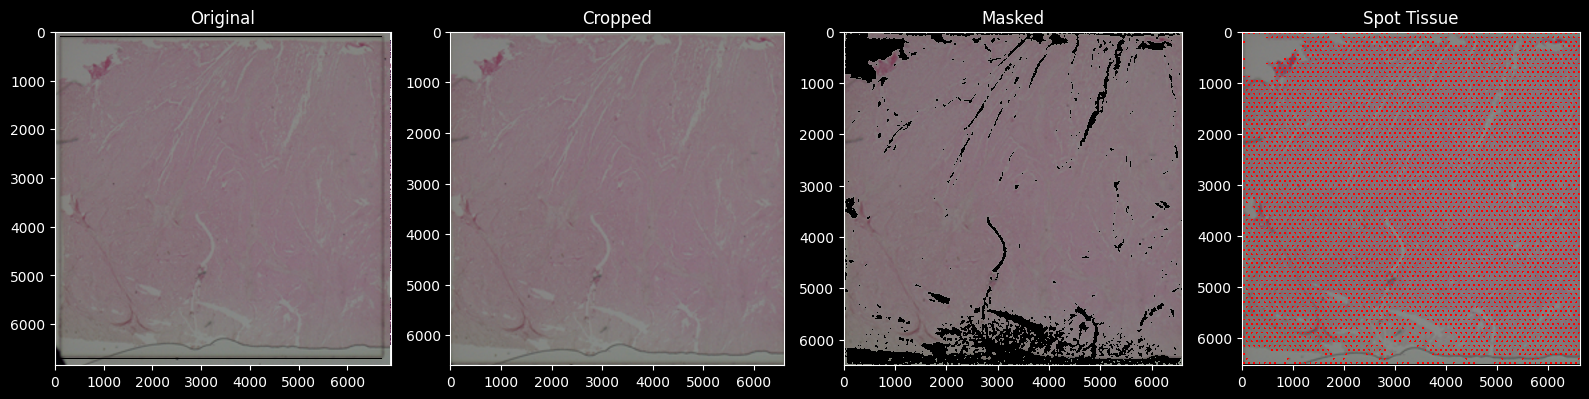

In [112]:
fig = plt.figure(tight_layout=True, figsize=(16, 5))

grid_size = res.get("grid_size", process_params.grid_size)
block_size = res.get("block_size") if params.type == "square" else None
spot_radius = res.get("r") if params.type in ("dy", "s3000") else None

tissue_img = img.get_cropped_tissue(
    rect_hull,
    matrix,
    process_params.scale_factor,
    grid_size,
    res["gap_size"],
    block_size,
    spot_radius,
    params.type,
)

# Full overlay is too dense for s3000; show raw tissue here and use a zoomed
# preview (below) to inspect spot gaps/circles.
if params.type == "s3000":
    tissue_display = img.crop_image(rect_hull, "raw")
    tissue_display = scale_image(tissue_display, process_params.scale_factor)
    tissue_title = "Tissue (no overlay)"
else:
    tissue_display = tissue_img
    tissue_title = "Spot Tissue"

gs = GridSpec(
    1,
    4,
    figure=fig,
    width_ratios=[
        img.img_raw.shape[1] / img.img_raw.shape[0],
        cropped_img.shape[1] / cropped_img.shape[0],
        thresholded_img.shape[1] / thresholded_img.shape[0],
        tissue_display.shape[1] / tissue_display.shape[0],
    ],
)

ax0 = fig.add_subplot(gs[0, 0])
ax0.set_title("Original")
ax0.imshow(img.img_raw[:, :, ::-1], interpolation="nearest")

ax1 = fig.add_subplot(gs[0, 1])
ax1.set_title("Cropped")
ax1.imshow(cropped_img[:, :, ::-1], interpolation="nearest")

ax1 = fig.add_subplot(gs[0, 2])
ax1.set_title("Masked")
ax1.imshow(thresholded_img[:, :, ::-1], interpolation="nearest")

ax2 = fig.add_subplot(gs[0, 3])
ax2.set_title(tissue_title)
ax2.imshow(tissue_display[:, :, ::-1], interpolation="nearest")

plt.show()


### Generate 10x data

In [113]:
# Zoomed spot preview to inspect gaps/circle shape (s3000 only).
if params.type == "s3000":
    preview_size = 512
    preview_scale = 2
    h, w = tissue_img.shape[:2]
    cy, cx = h // 2, w // 2
    y0 = max(0, cy - preview_size // 2)
    x0 = max(0, cx - preview_size // 2)
    preview = tissue_img[y0 : y0 + preview_size, x0 : x0 + preview_size]
    preview = cv2.resize(
        preview,
        None,
        fx=preview_scale,
        fy=preview_scale,
        interpolation=cv2.INTER_NEAREST,
    )
    plt.figure(figsize=(6, 6))
    plt.title("s3000 spot preview (zoomed)")
    plt.imshow(preview[:, :, ::-1], interpolation="nearest")
    plt.axis("off")
    plt.imsave("test.png", preview[:,:,::-1])
    plt.show()


In [114]:
os.makedirs(f"result/{img.name}", exist_ok=True)

fig.savefig(f"result/{img.name}/process.png")

fullres = img.crop_image(hull, "raw")
cv2.imwrite(f"result/{img.name}/tissue_fullres_image.png", fullres)

low_scale, hi_scale = 0.1, 0.5

lowres = scale_image(fullres, low_scale)
cv2.imwrite(f"result/{img.name}/tissue_lowres_image.png", lowres)
hires = scale_image(fullres, hi_scale)
cv2.imwrite(f"result/{img.name}/tissue_hires_image.png", hires)

True

In [115]:
low_side, hi_side, full_side = lowres.shape[0], hires.shape[0], fullres.shape[0]
tissue_hires_scalef = hi_side / full_side
tissue_lowres_scalef = low_side / full_side

if "block_size" in res:
    spot_diameter_fullres = float(res["block_size"][0])
else:
    spot_diameter_fullres = float(2 * res["r"])

scalefactor_json = json.dumps(
    {
        "tissue_hires_scalef": tissue_hires_scalef,
        "tissue_lowres_scalef": tissue_lowres_scalef,
        "spot_diameter_fullres": spot_diameter_fullres,
        "fiducial_diameter_fullres": 0.027,
    },
    indent=4,
)

with open(f"result/{img.name}/scalefactors_json.json", "w") as f:
    f.write(scalefactor_json)


In [116]:
tissue_position = pd.DataFrame(
    {
        "barcode": [],
        "in_tissue": [],
        "array_row": [],
        "array_col": [],
        "pxl_row_in_fullres": [],
        "pxl_col_in_fullres": [],
        # "type": [],
    }
).astype(
    {
        "barcode": str,
        "in_tissue": int,
        "array_row": int,
        "array_col": int,
        "pxl_row_in_fullres": int,
        "pxl_col_in_fullres": int,
        # "type": int,
    }
)

grid_size = res.get("grid_size", process_params.grid_size)
grid_size_x, grid_size_y = grid_size
gap_size_x, gap_size_y = res["gap_size"]

cols = np.arange(grid_size_x)
rows = np.arange(grid_size_y)
col_idx, row_idx = np.meshgrid(cols, rows, indexing="xy")

is_tissue = matrix[col_idx, row_idx].astype(int)
array_row = (grid_size_y - row_idx).astype(int)
array_col = (col_idx + 1).astype(int)

if params.type == "square":
    block_size_x, block_size_y = res["block_size"]
    x_pos = col_idx * (block_size_x + gap_size_x) + gap_size_x
    y_pos = row_idx * (block_size_y + gap_size_y) + gap_size_y
elif params.type in ("dy", "s3000"):
    row_offset = (row_idx % 2) * (gap_size_x / 2.0)
    if params.type == "dy":
        r = res["r"]
        x_pos = r + col_idx * gap_size_x + row_offset
        y_pos = r + row_idx * gap_size_y
    else:
        x_pos = gap_size_x + col_idx * gap_size_x + row_offset
        y_pos = gap_size_y + row_idx * gap_size_y
else:
    raise ValueError(f"Unknown grid type: {params.type}")

# Note: large grids (e.g., s3000) will produce large tables.
tissue_position = pd.DataFrame(
    {
        "barcode": "",
        "in_tissue": is_tissue.ravel(order="C"),
        "array_row": array_row.ravel(order="C"),
        "array_col": array_col.ravel(order="C"),
        "pxl_row_in_fullres": np.rint(y_pos).astype(int).ravel(order="C"),
        "pxl_col_in_fullres": np.rint(x_pos).astype(int).ravel(order="C"),
        # "type": matrix2.ravel(order="C"),
    }
)

tissue_position = tissue_position.sort_values(
    by=["array_row", "array_col"], ascending=[True, True]
).reset_index(drop=True)

tissue_position.to_csv(f"result/{img.name}/tissue_positions.csv", index=False)


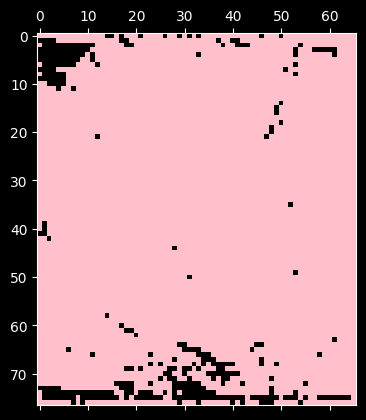

In [117]:
# Keep matrix-only view for non-s3000 layouts.
if params.type != "s3000":
    cmap = plt.cm.colors.ListedColormap(["black", "pink"])
    plt.matshow(matrix.T, cmap=cmap)
    plt.show()


20
(np.float64(100.04552352048559), np.float64(85.03869499241276)) 20.00910470409712


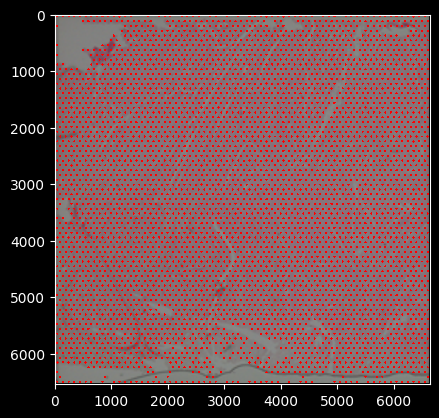

In [118]:
if params.type != "s3000":
    grid_size = res.get("grid_size", process_params.grid_size)
    block_size = res.get("block_size") if params.type == "square" else None
    spot_radius = res.get("r") if params.type in ("dy", "s3000") else None

    tissue_img = img.get_cropped_tissue(
        rect_hull,
        matrix,
        process_params.scale_factor,
        grid_size,
        res["gap_size"],
        block_size,
        spot_radius,
        params.type,
    )
    plt.imshow(tissue_img[:, :, ::-1], interpolation="nearest")

